<a href="https://colab.research.google.com/github/thekuljeetcharak/Anomaly-Detection-Project-mini-ISA/blob/main/AnomalyDetectionISA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Import** is used to add library in python
**Pandas** is used to analize the data, manipulate the data , read the data. Import pandas as pd the pd is the alias name of pandas, whenever we need the Pandas library we can just use the alias name of the pandas i.e., pd.
**Numpy** it stands for numerical python which is used to perform mathematical operation. It also have the alias name called the np.
**Matplotlib** use to create graph, chart etc. this library help us to visualize the data.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

These line of code is used to upload the dataset from the local files/ storage

In [ ]:
from google.colab import files
uploaded = files.upload()
#print(uploaded)

The first line of the code is used to read the data of the uploded file and save into the variable data. In the second line data.head() is used to show the content of the first five rows of the dataset.

In [ ]:
data = pd.read_csv("dataset.csv")
data.head()

,segment,anomaly,train,channel,sampling,duration,len,mean,var,std,...,smooth10_n_peaks,smooth20_n_peaks,diff_peaks,diff2_peaks,diff_var,diff2_var,gaps_squared,len_weighted,var_div_duration,var_div_len
0,1,1,1,CADC0872,1,279,280,8.533143e-07,3.494283e-10,0.000019,...,3,2,4,6,1.271176e-10,2.960666e-10,279,280,1.252431e-12,1.247958e-12
1,2,1,1,CADC0872,1,476,477,-3.639396e-06,6.476485e-10,0.000025,...,1,1,5,8,1.489383e-12,3.004752e-12,476,477,1.360606e-12,1.357754e-12
2,3,1,1,CADC0872,1,594,595,1.170788e-05,5.592877e-10,0.000024,...,2,2,2,3,4.112280e-12,1.029918e-11,594,595,9.415618e-13,9.399794e-13
3,4,1,1,CADC0872,1,271,272,8.486808e-07,5.466024e-10,0.000023,...,2,2,3,6,2.475760e-11,6.240985e-11,271,272,2.016983e-12,2.009568e-12
4,5,0,0,CADC0872,1,256,257,1.058485e-05,5.279023e-10,0.000023,...,1,1,78,87,5.547101e-13,7.035422e-13,256,257,2.062118e-12,2.054094e-12


In [ ]:
data.tail()

,anomaly,train,sampling,duration,len,mean,var,std,kurtosis,skew,...,smooth20_n_peaks,diff_peaks,diff2_peaks,diff_var,diff2_var,gaps_squared,len_weighted,var_div_duration,var_div_len,iso_anomaly
2118,0,0,5,155,32,-0.000026,1.365061e-10,0.000012,-1.465830,-0.023716,...,1,4,7,5.643170e-12,9.612178e-13,775,160,8.806842e-13,4.265814e-12,0
2119,0,1,5,165,34,-0.000023,1.988522e-10,0.000014,-1.490978,-0.038516,...,1,4,9,7.349826e-12,1.162888e-12,825,170,1.205165e-12,5.848595e-12,0
2120,0,1,5,140,29,-0.000031,1.146533e-10,0.000011,-1.504177,0.013923,...,1,3,7,5.763149e-12,9.522562e-13,700,145,8.189522e-13,3.953562e-12,0
2121,0,1,5,200,41,-0.000005,7.755461e-10,0.000028,-1.470041,-0.002828,...,1,2,12,1.837184e-11,1.123874e-12,1000,205,3.877731e-12,1.891576e-11,0
2122,1,1,5,145,30,-0.000014,2.918613e-10,0.000017,-0.980284,-0.184419,...,2,1,1,2.448748e-10,7.221565e-10,725,150,2.012836e-12,9.728709e-12,0


Used to check how many number of the rows and colums that the dataset contain.

In [ ]:
data.shape

(2123, 23)

In [ ]:
data.columns

Index(['segment', 'anomaly', 'train', 'channel', 'sampling', 'duration', 'len',
       'mean', 'var', 'std', 'kurtosis', 'skew', 'n_peaks', 'smooth10_n_peaks',
       'smooth20_n_peaks', 'diff_peaks', 'diff2_peaks', 'diff_var',
       'diff2_var', 'gaps_squared', 'len_weighted', 'var_div_duration',
       'var_div_len'],
      dtype='object')

In [ ]:
data.isnull().sum()

,0
segment,0
anomaly,0
train,0
channel,0
sampling,0
duration,0
len,0
mean,0
var,0
std,0


In [ ]:
data.describe()

,segment,anomaly,train,sampling,duration,len,mean,var,std,kurtosis,...,smooth10_n_peaks,smooth20_n_peaks,diff_peaks,diff2_peaks,diff_var,diff2_var,gaps_squared,len_weighted,var_div_duration,var_div_len
count,2123.000000,2123.000000,2123.000000,2123.000000,2123.000000,2123.000000,2.123000e+03,2.123000e+03,2123.000000,2123.000000,...,2123.000000,2123.000000,2123.000000,2123.000000,2.123000e+03,2.123000e+03,2123.000000,2123.000000,2.123000e+03,2.123000e+03
mean,1062.000000,0.204428,0.750824,3.505888,265.613754,142.954781,1.109677e-01,3.065868e-02,0.096226,-1.085494,...,1.110221,1.181818,18.110692,25.286387,9.166359e-04,1.045846e-03,999.228450,267.925106,1.176063e-04,4.361427e-04
std,613.001631,0.403378,0.432638,1.935418,167.158550,152.329786,1.963165e-01,5.491161e-02,0.146319,1.000566,...,0.399227,0.425295,28.991979,32.737797,4.196259e-03,1.127395e-02,1565.349081,166.245528,2.119295e-04,8.845658e-04
min,1.000000,0.000000,0.000000,1.000000,35.000000,8.000000,-3.833030e-05,1.422763e-11,0.000004,-1.858813,...,0.000000,0.000000,0.000000,0.000000,1.962330e-13,3.875356e-13,104.000000,40.000000,2.817267e-14,4.404840e-14
25%,531.500000,0.000000,1.000000,1.000000,175.000000,40.000000,-7.239804e-07,2.960552e-10,0.000017,-1.449123,...,1.000000,1.000000,1.000000,4.000000,3.163852e-12,1.233331e-12,295.000000,175.000000,1.309137e-12,2.809916e-12
50%,1062.000000,0.000000,1.000000,5.000000,225.000000,70.000000,4.515496e-06,6.032890e-10,0.000025,-1.302729,...,1.000000,1.000000,5.000000,14.000000,3.640618e-11,1.095135e-11,500.000000,230.000000,3.786876e-12,1.563517e-11
75%,1592.500000,0.000000,1.000000,5.000000,330.000000,201.000000,2.051710e-01,3.738843e-02,0.193361,-0.996211,...,1.000000,1.000000,21.000000,32.000000,2.982598e-04,1.402282e-04,1200.000000,330.000000,1.886576e-04,4.718514e-04
max,2123.000000,1.000000,1.000000,5.000000,1335.000000,1040.000000,1.118632e+00,2.724801e-01,0.521996,31.201842,...,5.000000,4.000000,240.000000,256.000000,9.987869e-02,3.033986e-01,20750.000000,1340.000000,1.686516e-03,8.031028e-03


In [ ]:
# Handle missing values
data.ffill(inplace=True)

In [ ]:
data.dtypes

,0
segment,int64
anomaly,int64
train,int64
channel,object
sampling,int64
duration,int64
len,int64
mean,float64
var,float64
std,float64


In [ ]:
numeric_data = data.select_dtypes(include=[np.number])

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(numeric_data)

In [ ]:
scaled_data = pd.DataFrame(scaled_data, columns=numeric_data.columns)

In [ ]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(contamination=0.02)

model.fit(scaled_data)

predictions = model.predict(scaled_data)

In [ ]:
data.columns

Index(['segment', 'anomaly', 'train', 'channel', 'sampling', 'duration', 'len',
       'mean', 'var', 'std', 'kurtosis', 'skew', 'n_peaks', 'smooth10_n_peaks',
       'smooth20_n_peaks', 'diff_peaks', 'diff2_peaks', 'diff_var',
       'diff2_var', 'gaps_squared', 'len_weighted', 'var_div_duration',
       'var_div_len'],
      dtype='object')

In [ ]:
# Remove text columns
data = data.drop(columns=['segment','channel'])

# Separate features and label
X = data.drop(columns=['anomaly','train'])
y = data['anomaly']

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
import pandas as pd

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100)

model.fit(X_scaled, y)

RandomForestClassifier()

In [ ]:
predictions = model.predict(X_scaled)

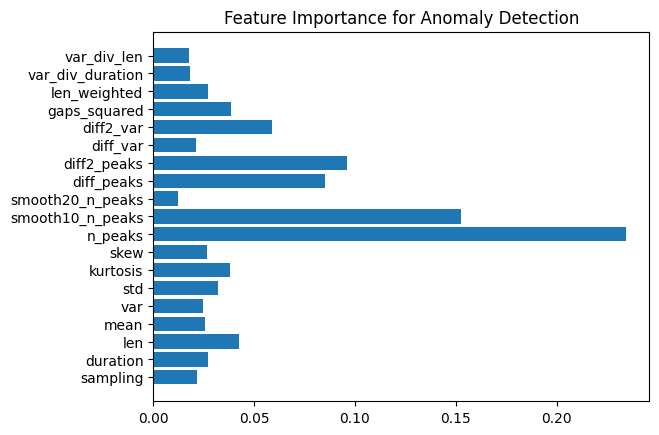

In [ ]:
import matplotlib.pyplot as plt

importance = model.feature_importances_

plt.barh(X.columns, importance)
plt.title("Feature Importance for Anomaly Detection")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100)

model.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
predictions = model.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.96      0.99      0.98       337
           1       0.96      0.84      0.90        88

    accuracy                           0.96       425
   macro avg       0.96      0.92      0.94       425
weighted avg       0.96      0.96      0.96       425



In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)

print(cm)

[[334   3]
 [ 14  74]]


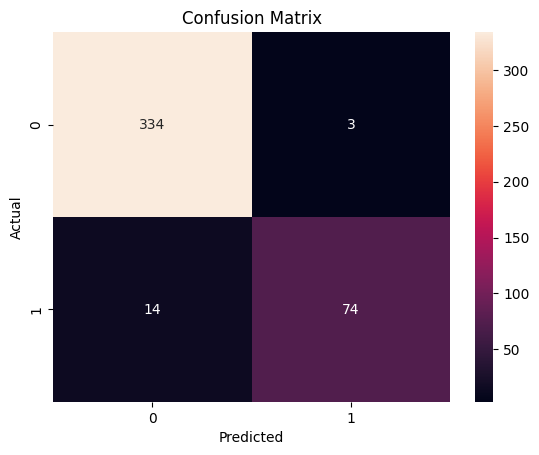

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
from sklearn.ensemble import IsolationForest

In [ ]:
iso_model = IsolationForest(
    n_estimators=100,
    contamination=0.2,
    random_state=42
)

iso_model.fit(X_scaled)

IsolationForest(contamination=0.2, random_state=42)

In [ ]:
iso_predictions = iso_model.predict(X_scaled)

In [ ]:
iso_predictions = [1 if x == -1 else 0 for x in iso_predictions]

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y, iso_predictions))

              precision    recall  f1-score   support

           0       0.82      0.82      0.82      1689
           1       0.29      0.28      0.29       434

    accuracy                           0.71      2123
   macro avg       0.55      0.55      0.55      2123
weighted avg       0.71      0.71      0.71      2123



In [ ]:
data['iso_anomaly'] = iso_predictions

In [ ]:
data['iso_anomaly'].value_counts()

,count
iso_anomaly,
0,1698
1,425


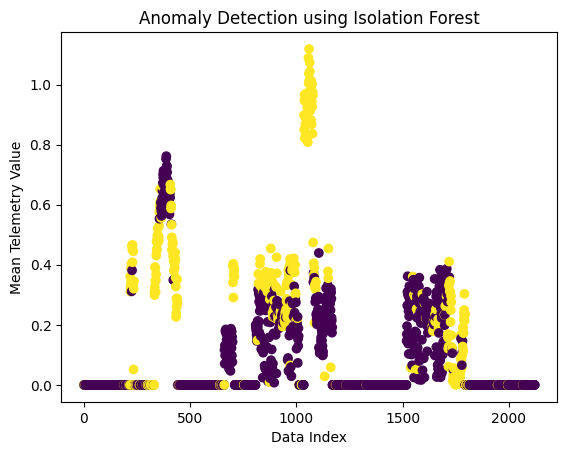

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(range(len(data)), data['mean'], c=data['iso_anomaly'])

plt.title("Anomaly Detection using Isolation Forest")
plt.xlabel("Data Index")
plt.ylabel("Mean Telemetry Value")

plt.show()

In [ ]:
importance = model.feature_importances_

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

In [ ]:
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

             Feature  Importance
8            n_peaks    0.213608
9   smooth10_n_peaks    0.148098
12       diff2_peaks    0.111049
11        diff_peaks    0.079899
2                len    0.058110
14         diff2_var    0.052746
15      gaps_squared    0.044134
6           kurtosis    0.042089
5                std    0.031251
7               skew    0.030746
3               mean    0.029997
16      len_weighted    0.029688
1           duration    0.028296
13          diff_var    0.023700
0           sampling    0.019931
17  var_div_duration    0.018387
18       var_div_len    0.014549
4                var    0.013204
10  smooth20_n_peaks    0.010517


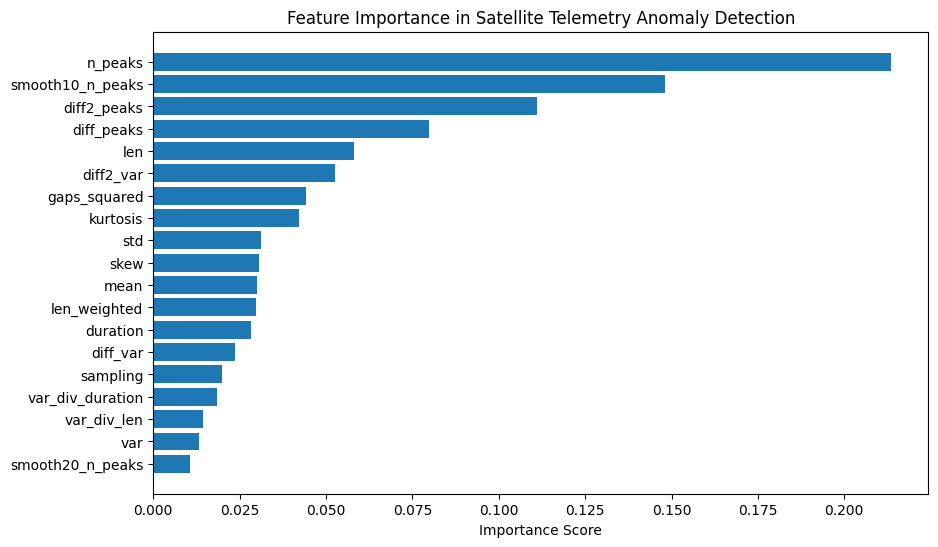

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.gca().invert_yaxis()

plt.title("Feature Importance in Satellite Telemetry Anomaly Detection")

plt.xlabel("Importance Score")

plt.show()

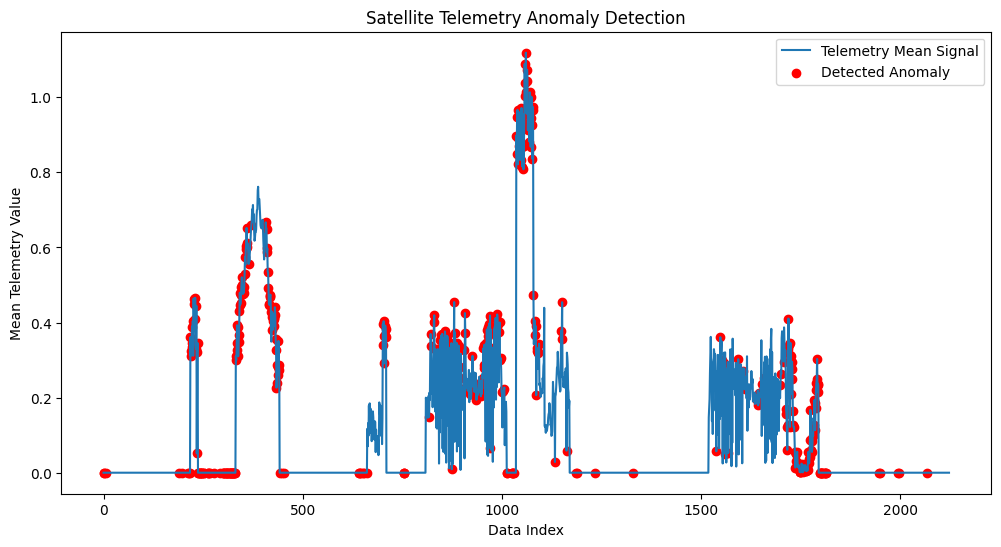

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

# Plot telemetry signal
plt.plot(data['mean'], label="Telemetry Mean Signal")

# Highlight anomalies
anomalies = data[data['iso_anomaly'] == 1]

plt.scatter(
    anomalies.index,
    anomalies['mean'],
    color='red',
    label="Detected Anomaly"
)

plt.title("Satellite Telemetry Anomaly Detection")
plt.xlabel("Data Index")
plt.ylabel("Mean Telemetry Value")

plt.legend()

plt.show()

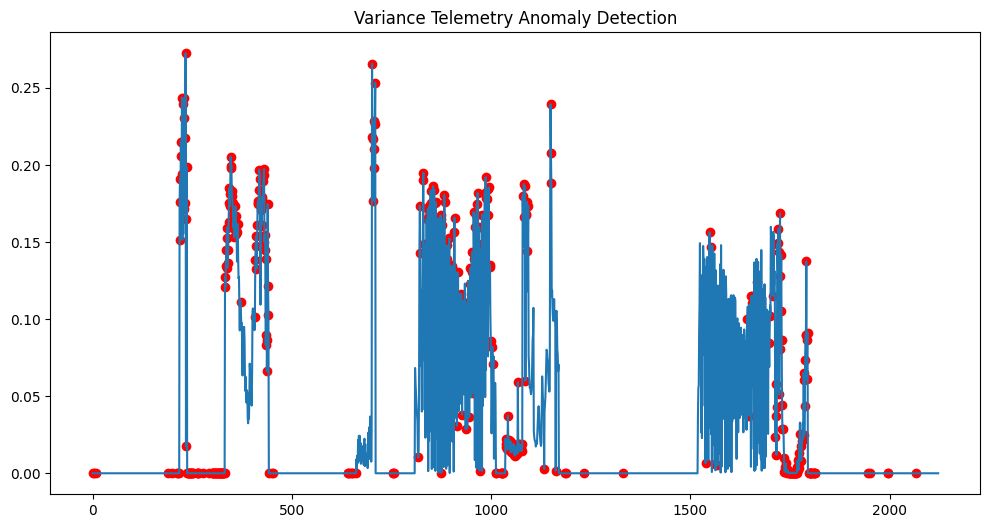

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(data['var'], label="Variance Signal")

anomalies = data[data['iso_anomaly'] == 1]

plt.scatter(
    anomalies.index,
    anomalies['var'],
    color='red'
)

plt.title("Variance Telemetry Anomaly Detection")

plt.show()

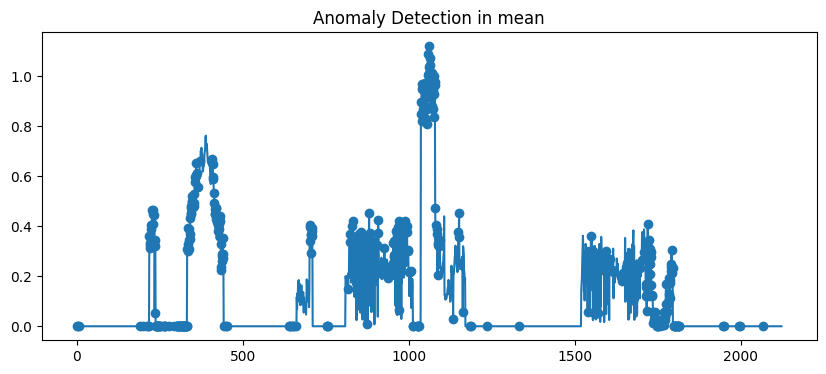

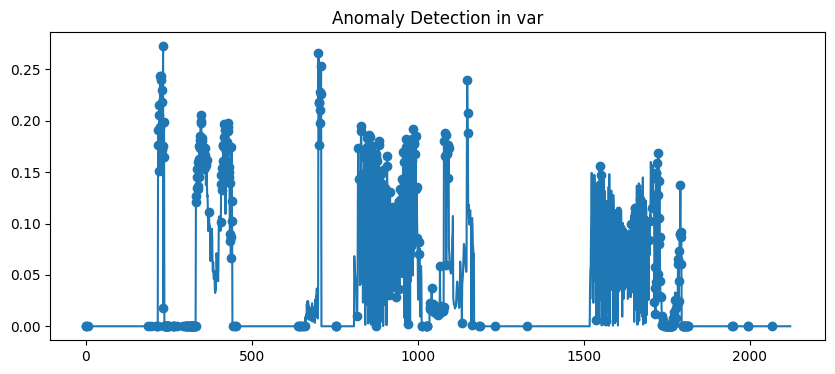

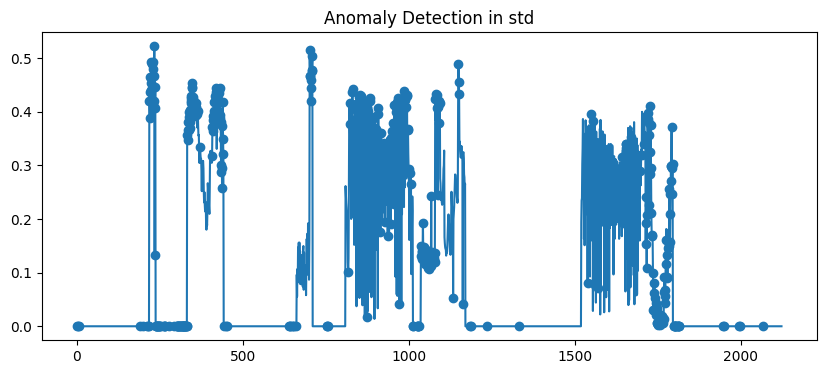

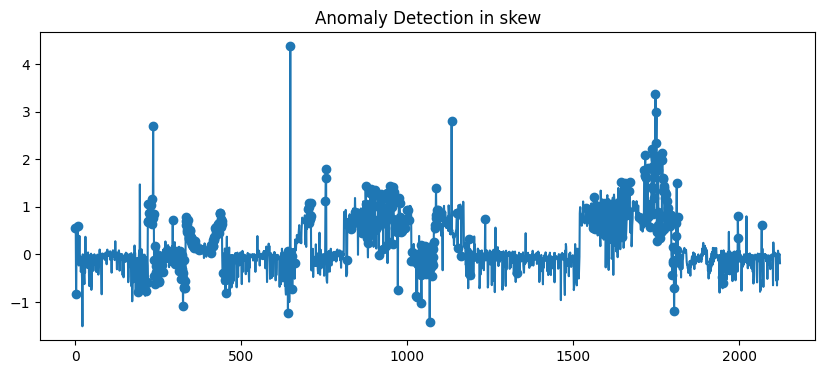

In [ ]:
features = ['mean','var','std','skew']

for feature in features:

    plt.figure(figsize=(10,4))

    plt.plot(data[feature])

    anomalies = data[data['iso_anomaly'] == 1]

    plt.scatter(
        anomalies.index,
        anomalies[feature]
    )

    plt.title(f"Anomaly Detection in {feature}")

    plt.show()